# Data Exploration - Reanalsysis (ERA5 and MERRA2)

In [1]:
import pathlib
import datetime

In [2]:
import numpy

In [3]:
import xarray

In [4]:
import matplotlib.pyplot
import cartopy

In [5]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/tutorial_202606'}


In [6]:
import pyearthtools.data
import pyearthtools.pipeline


In [7]:
import torch

### Define common parameters

In [8]:
select_dt = datetime.datetime(2025,5,11,15,0)

In [9]:
ghana_extents = {
    'latitude': (4.5,12.3),
    'longitude': (-3.8, 4.0),
}

In [10]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][0],
                 ghana_extents['longitude'][1],
                )

### MERRA2 dataset info
Reanalysis dataset used for aerosols
* dir location `/gws/nopw/j04/ew4energy/West_Africa_Merra-2pwd`
* file template `M2T1NXAER.5.12.4%3AMERRA2_401.tavg1_2d_aer_Nx.20200930.nc4.dap.nc4` 
* data time span 2015-2020
* data temporal resolution: 1 day per file


In [11]:
ew4_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')

In [12]:
meteo_fname_template = 'MERRA2_400.tavg1_2d_slv_Nx.{dt.year:04d}{dt.month:02d}{dt.day:02d}.SUB.nc'
aero_fname_template = 'MERRA2_400.inst3_3d_aer_Nv.{dt.year:04d}{dt.month:02d}{dt.day:02d}.SUB.nc'

In [13]:
merra2_meteo_dir = ew4_dir / 'West_Africa_Merra-2_2015-2025_meteo' 
merra2_meteo_dir

PosixPath('/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo')

In [14]:
merra2_aero_dir = ew4_dir / 'West_Africa_Merra-2_2015-2025_aerosols' / '3d'
merra2_aero_dir

PosixPath('/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d')

### Explore the meteological data variables.

In [15]:
merra2_meteo_sample = xarray.open_dataset(merra2_meteo_dir / f'{select_dt.year:04d}' / meteo_fname_template.format(dt=select_dt))

In [16]:
float(merra2_meteo_sample['lat'].min()), float(merra2_meteo_sample['lat'].max()), float(merra2_meteo_sample['lon'].min()), float(merra2_meteo_sample['lon'].max())

(0.5, 20.0, -20.0, 10.0)

In [17]:
merra2_meteo_sample

<xarray.Dataset> Size: 942kB
Dimensions:  (time: 24, lat: 40, lon: 49)
Coordinates:
  * time     (time) datetime64[ns] 192B 2025-05-11T00:30:00 ... 2025-05-11T23...
  * lat      (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.0 18.5 19.0 19.5 20.0
  * lon      (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
Data variables:
    T2M      (time, lat, lon) float32 188kB ...
    U10M     (time, lat, lon) float32 188kB ...
    U2M      (time, lat, lon) float32 188kB ...
    V10M     (time, lat, lon) float32 188kB ...
    V2M      (time, lat, lon) float32 188kB ...
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_slv_Nx.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   23:59:59.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [18]:
list(merra2_meteo_sample.variables)

['T2M', 'U10M', 'U2M', 'V10M', 'V2M', 'time', 'lon', 'lat']

In [19]:
float(min(merra2_meteo_sample['lat'])), float(max(merra2_meteo_sample['lat'])), float(min(merra2_meteo_sample['lon'])), float(max(merra2_meteo_sample['lon'])),

(0.5, 20.0, -20.0, 10.0)

<xarray.DataArray 'T2M' (time: 24, lat: 40, lon: 49)> Size: 188kB
[47040 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 192B 2025-05-11T00:30:00 ... 2025-05-11T23...
  * lat      (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.0 18.5 19.0 19.5 20.0
  * lon      (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
Attributes:
    standard_name:   2-meter_air_temperature
    long_name:       2-meter_air_temperature
    units:           K
    fmissing_value:  1e+15
    vmax:            1e+15
    vmin:            -1e+15

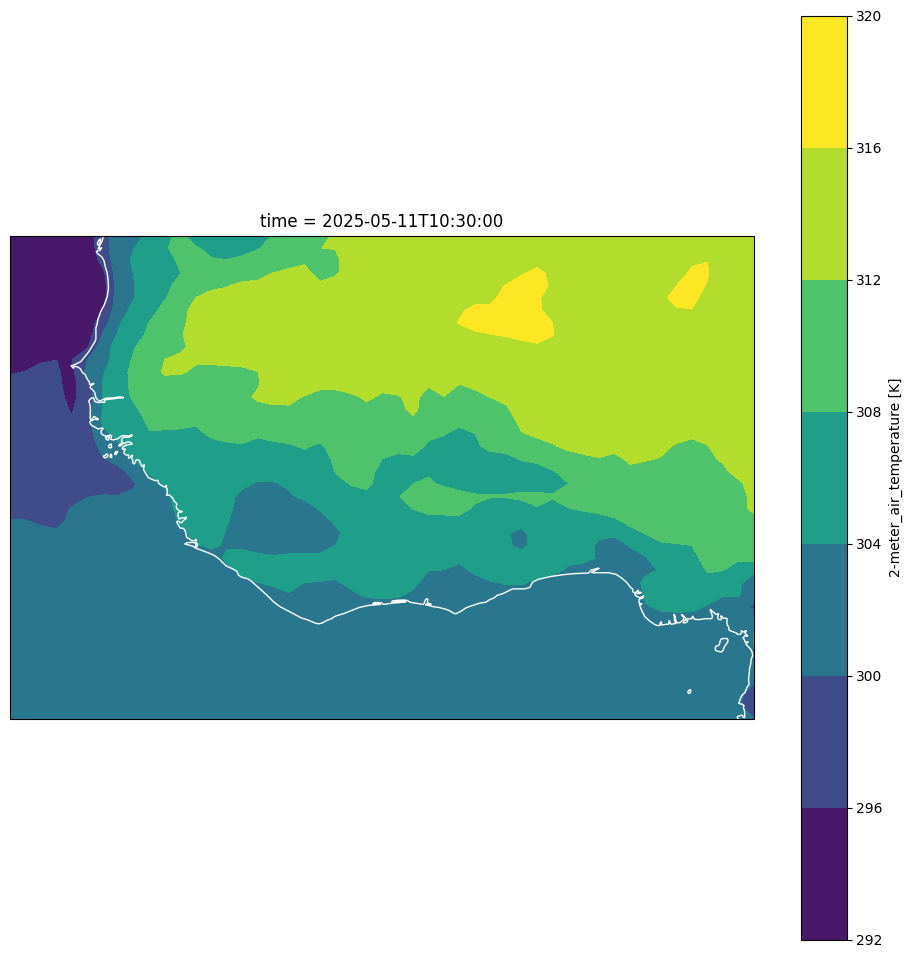

In [20]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
merra2_meteo_sample['T2M'][10].plot.contourf(ax=ax1)
ax1.coastlines(color='w')
merra2_meteo_sample['T2M']

### Explore the aerosol data variables

In [21]:
merra2_aero_sample = xarray.open_dataset(merra2_aero_dir / f'{select_dt.year:04d}' / aero_fname_template.format(dt=select_dt))

In [22]:
merra2_aero_sample

<xarray.Dataset> Size: 95MB
Dimensions:   (time: 8, lev: 72, lat: 40, lon: 49)
Coordinates:
  * time      (time) datetime64[ns] 64B 2025-05-11 ... 2025-05-11T21:00:00
  * lev       (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * lat       (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.5 19.0 19.5 20.0
  * lon       (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
Data variables: (12/23)
    AIRDENS   (time, lev, lat, lon) float32 5MB ...
    BCPHILIC  (time, lev, lat, lon) float32 5MB ...
    BCPHOBIC  (time, lev, lat, lon) float32 5MB ...
    DELP      (time, lev, lat, lon) float32 5MB ...
    DMS       (time, lev, lat, lon) float32 5MB ...
    DU001     (time, lev, lat, lon) float32 5MB ...
    ...        ...
    SO4       (time, lev, lat, lon) float32 5MB ...
    SS001     (time, lev, lat, lon) float32 5MB ...
    SS002     (time, lev, lat, lon) float32 5MB ...
    SS003     (time, lev, lat, lon) float32 5MB ...
    SS004     (time, lev, lat, lon) float32 5MB ...
    SS005     (time, lev, lat, lon) float32 5MB ...
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [23]:
list(merra2_aero_sample.variables)

['AIRDENS',
 'BCPHILIC',
 'BCPHOBIC',
 'DELP',
 'DMS',
 'DU001',
 'DU002',
 'DU003',
 'DU004',
 'DU005',
 'LWI',
 'MSA',
 'OCPHILIC',
 'OCPHOBIC',
 'PS',
 'RH',
 'SO2',
 'SO4',
 'SS001',
 'SS002',
 'SS003',
 'SS004',
 'SS005',
 'time',
 'lon',
 'lat',
 'lev']

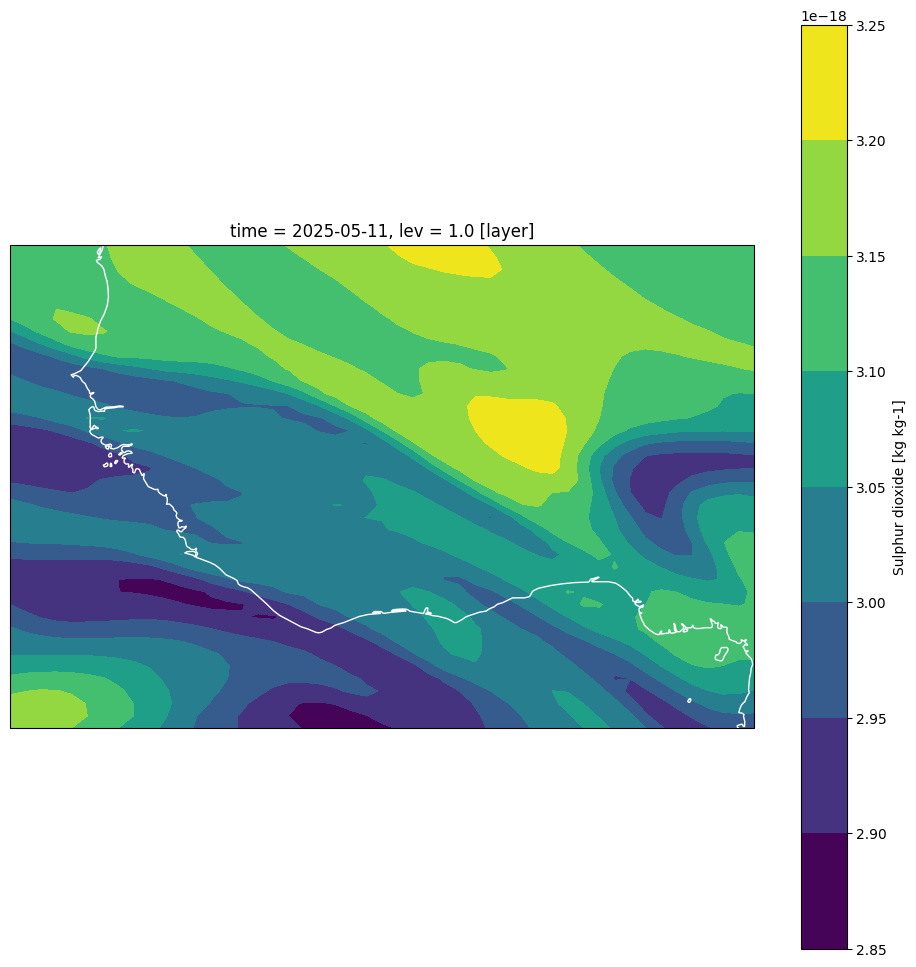

In [24]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
merra2_aero_sample['SO2'][0][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


If we merge the two datasets, we can see what this will look like. This might the sort of dataset that we want to get out of our loader.

In [25]:
xarray.merge([merra2_aero_sample['SO2'], merra2_meteo_sample['U10M'], merra2_aero_sample['SO4'], merra2_meteo_sample['V10M']])

/tmp/ipykernel_1478/1519744771.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  xarray.merge([merra2_aero_sample['SO2'], merra2_meteo_sample['U10M'], merra2_aero_sample['SO4'], merra2_meteo_sample['V10M']])


<xarray.Dataset> Size: 37MB
Dimensions:  (time: 32, lon: 49, lat: 40, lev: 72)
Coordinates:
  * time     (time) datetime64[ns] 256B 2025-05-11 ... 2025-05-11T23:30:00
  * lon      (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
  * lat      (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.0 18.5 19.0 19.5 20.0
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
Data variables:
    SO2      (time, lev, lat, lon) float32 18MB 3.17e-18 3.169e-18 ... nan nan
    U10M     (time, lat, lon) float32 251kB nan nan nan ... -1.473 -0.9395
    SO4      (time, lev, lat, lon) float32 18MB 1.76e-23 1.807e-23 ... nan nan
    V10M     (time, lat, lon) float32 251kB nan nan nan ... 3.164 2.871 1.969
Attributes:
    standard_name:   Sulphur dioxide
    long_name:       Sulphur dioxide
    units:           kg kg-1
    fmissing_value:  1e+15
    vmax:            1e+15
    vmin:            -1e+15

## Load the data in pyearthtools

In [26]:
ew4_merra2_aero_accessor = pyearthtools.data.archive.ew4_merra2_aero(['SO2', 'SO4'])
ew4_merra2_aero_accessor

All selected variables present in the dataset.


Ew4Merra2Aero
	Description                    MERRA2 
		 range                          '2019 to 2025'
		 Documentation                  'https://gmao.gsfc.nasa.gov/gmao-products/merra-2/'


	Initialisation                 
		 variables                      ['SO2', 'SO4']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Trim                           {'__args': '()', 'variables': "['SO2', 'SO4']"}

In [27]:
ew4_merra2_aero_accessor[select_dt]

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(


<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1, lev: 72, latitude: 40, longitude: 49)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-05-11T15:00:00
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 320B 0.5 1.0 1.5 2.0 ... 18.5 19.0 19.5 20.0
  * longitude  (longitude) float64 392B -20.0 -19.38 -18.75 ... 8.75 9.375 10.0
Data variables:
    SO2        (time, lev, latitude, longitude) float32 564kB dask.array<chunksize=(1, 72, 40, 49), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 564kB dask.array<chunksize=(1, 72, 40, 49), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [28]:
ew4_merra2_meteo_accessor = pyearthtools.data.archive.ew4_merra2_meteo(['T2M', 'U2M'])
ew4_merra2_meteo_accessor

All selected variables present in the dataset.


Ew4Merra2Meteo
	Description                    MERRA2 
		 range                          '2019 to 2025'
		 Documentation                  'https://gmao.gsfc.nasa.gov/gmao-products/merra-2/'


	Initialisation                 
		 variables                      ['T2M', 'U2M']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Trim                           {'__args': '()', 'variables': "['T2M', 'U2M']"}
		 MeteoHourFix                   {}

In [29]:
ew4_merra2_meteo_accessor[select_dt]

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(


<xarray.Dataset> Size: 16kB
Dimensions:    (time: 1, latitude: 40, longitude: 49)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-05-11T15:00:00
  * latitude   (latitude) float64 320B 0.5 1.0 1.5 2.0 ... 18.5 19.0 19.5 20.0
  * longitude  (longitude) float64 392B -20.0 -19.38 -18.75 ... 8.75 9.375 10.0
Data variables:
    U2M        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 40, 49), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 40, 49), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_slv_Nx.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   23:59:59.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [30]:
ew4_merra_load_pipe = pyearthtools.pipeline.Pipeline(
    (ew4_merra2_aero_accessor, ew4_merra2_meteo_accessor),
    pyearthtools.pipeline.operations.xarray.Merge(),
)
ew4_merra_load_pipe[select_dt]



/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(


<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1, lev: 72, latitude: 40, longitude: 49)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-05-11T15:00:00
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 320B 0.5 1.0 1.5 2.0 ... 18.5 19.0 19.5 20.0
  * longitude  (longitude) float64 392B -20.0 -19.38 -18.75 ... 8.75 9.375 10.0
Data variables:
    SO2        (time, lev, latitude, longitude) float32 564kB dask.array<chunksize=(1, 72, 40, 49), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 564kB dask.array<chunksize=(1, 72, 40, 49), meta=np.ndarray>
    U2M        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 40, 49), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 40, 49), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


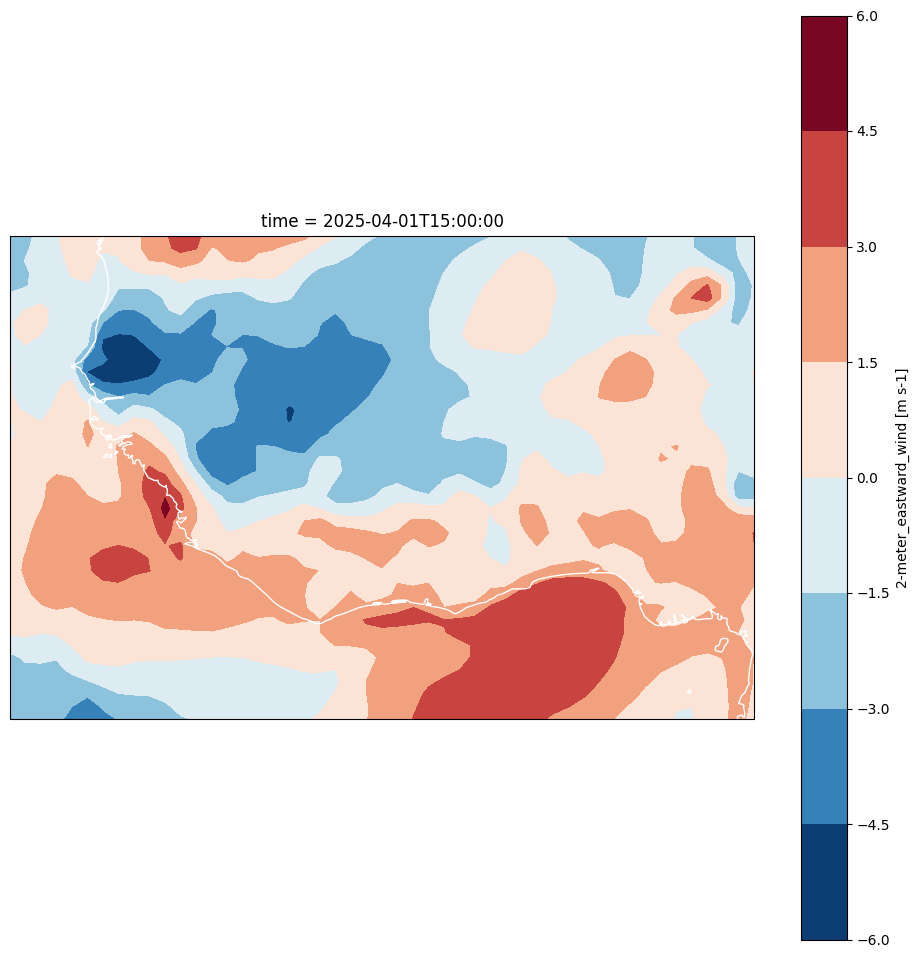

In [31]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_merra_load_pipe['2025-04-01 15:00']['U2M'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

In [32]:
ew4_merra2_pipeline = pyearthtools.pipeline.Pipeline(
    (ew4_merra2_aero_accessor, ew4_merra2_meteo_accessor),
    pyearthtools.pipeline.operations.xarray.Merge(),
    # pyearthtools.data.transform.region.Bounding(*ghana_pet_box),  
    pyearthtools.pipeline.operations.xarray.select.SliceDataset(slices=ghana_extents),
    pyearthtools.pipeline.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=pyearthtools.data.time.TimeDelta('30 minutes')),
    iterator=pyearthtools.pipeline.iterators.DateRange('20250401T00', '20250901T00', interval='3 hours'), 
    exceptions_to_ignore=pyearthtools.data.exceptions.DataNotFoundError,
)

In [33]:
predictor, target = ew4_merra2_pipeline[select_dt]

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. nanosecond > hour
  warnings.warn(


In [34]:
predictor[0]

<xarray.Dataset> Size: 122kB
Dimensions:    (time: 1, lev: 72, latitude: 16, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-05-11T15:00:00
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 128B 4.5 5.0 5.5 6.0 ... 10.5 11.0 11.5 12.0
  * longitude  (longitude) float64 104B -3.75 -3.125 -2.5 ... 2.5 3.125 3.75
Data variables:
    SO2        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    U2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [35]:
target[0]

<xarray.Dataset> Size: 122kB
Dimensions:    (time: 1, lev: 72, latitude: 16, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-05-11T15:00:00
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 128B 4.5 5.0 5.5 6.0 ... 10.5 11.0 11.5 12.0
  * longitude  (longitude) float64 104B -3.75 -3.125 -2.5 ... 2.5 3.125 3.75
Data variables:
    SO2        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    U2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

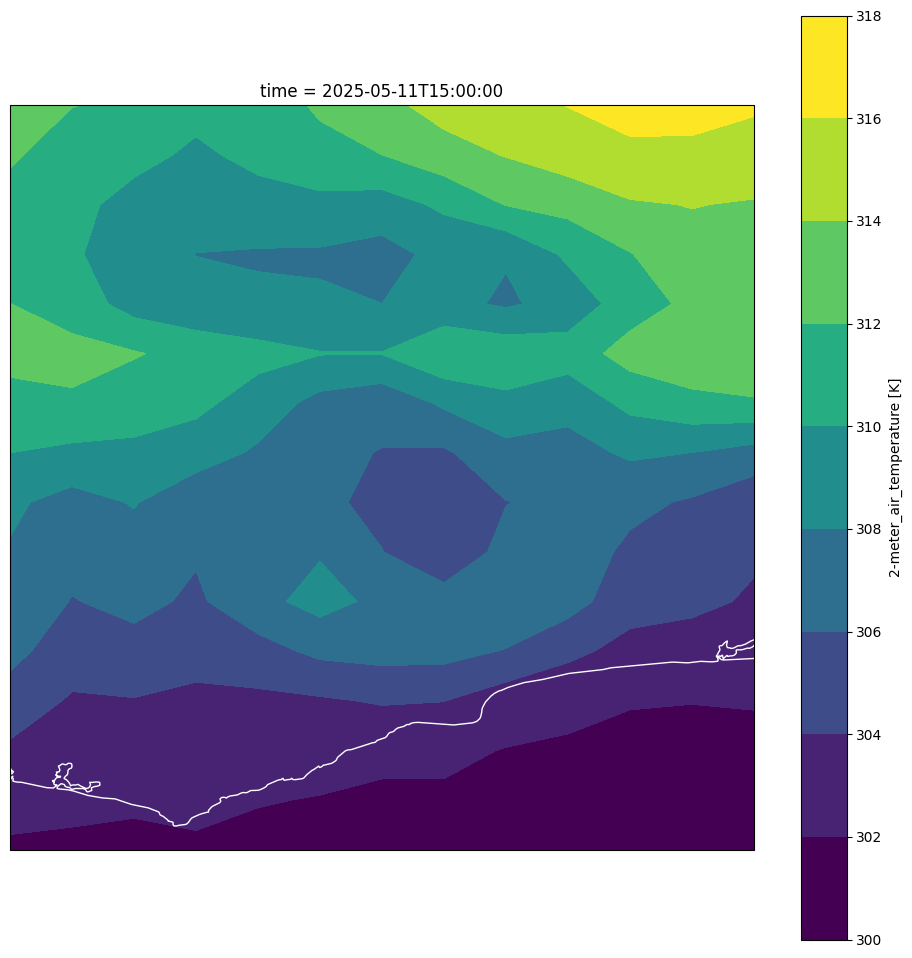

In [36]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
target[0]['T2M'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

In [37]:
pred_n, target_n = next(iter(ew4_merra2_pipeline))

In [38]:
pred_n[0]

<xarray.Dataset> Size: 122kB
Dimensions:    (time: 1, lev: 72, latitude: 16, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-04-01
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 128B 4.5 5.0 5.5 6.0 ... 10.5 11.0 11.5 12.0
  * longitude  (longitude) float64 104B -3.75 -3.125 -2.5 ... 2.5 3.125 3.75
Data variables:
    SO2        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    U2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Fri Apr 11 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250401.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-04-01
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-04-01
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

In [39]:
target_n[0]

<xarray.Dataset> Size: 122kB
Dimensions:    (time: 1, lev: 72, latitude: 16, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-04-01
  * lev        (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * latitude   (latitude) float64 128B 4.5 5.0 5.5 6.0 ... 10.5 11.0 11.5 12.0
  * longitude  (longitude) float64 104B -3.75 -3.125 -2.5 ... 2.5 3.125 3.75
Data variables:
    SO2        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    SO4        (time, lev, latitude, longitude) float32 60kB dask.array<chunksize=(1, 72, 16, 13), meta=np.ndarray>
    U2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
    T2M        (time, latitude, longitude) float32 832B dask.array<chunksize=(1, 16, 13), meta=np.ndarray>
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Fri Apr 11 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250401.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-04-01
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-04-01
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

# ERA5 Reanalsyis Dataset

### ERA5 Intial Exploration
For the purposes of this tutorial, I have downloaded a subset from the Copernicus Climate Data Store to demonstrate its use.

In [40]:
era5_ew4_dir = ew4_dir / 'ERA5' / 'tutorial_202606'

In [41]:
era5_fname_template = 'era5_pl_{dt.year:04d}_{dt.month:02d}_vertical_velocity.nc'

In [42]:
select_dt = datetime.datetime(2025,7,23,9,0)

In [43]:
era5_sample = xarray.open_dataset(era5_ew4_dir / era5_fname_template.format(dt=select_dt))

In [44]:
era5_sample

<xarray.Dataset> Size: 284MB
Dimensions:         (valid_time: 744, pressure_level: 5, latitude: 101,
                     longitude: 189)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2025-07-01 ... 2025-07-31...
    expver          (valid_time) <U4 12kB ...
  * pressure_level  (pressure_level) float64 40B 1e+03 850.0 700.0 500.0 200.0
  * latitude        (latitude) float64 808B 27.0 26.75 26.5 ... 2.5 2.25 2.0
  * longitude       (longitude) float64 2kB -20.0 -19.75 -19.5 ... 26.75 27.0
    number          int64 8B ...
Data variables:
    w               (valid_time, pressure_level, latitude, longitude) float32 284MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-02T11:13 GRIB to CDM+CF via cfgrib-0.9.1...

In [45]:
float(era5_sample['latitude'].min()), float(era5_sample['latitude'].max()), float(era5_sample['longitude'].min()), float(era5_sample['longitude'].max())

(2.0, 27.0, -20.0, 27.0)

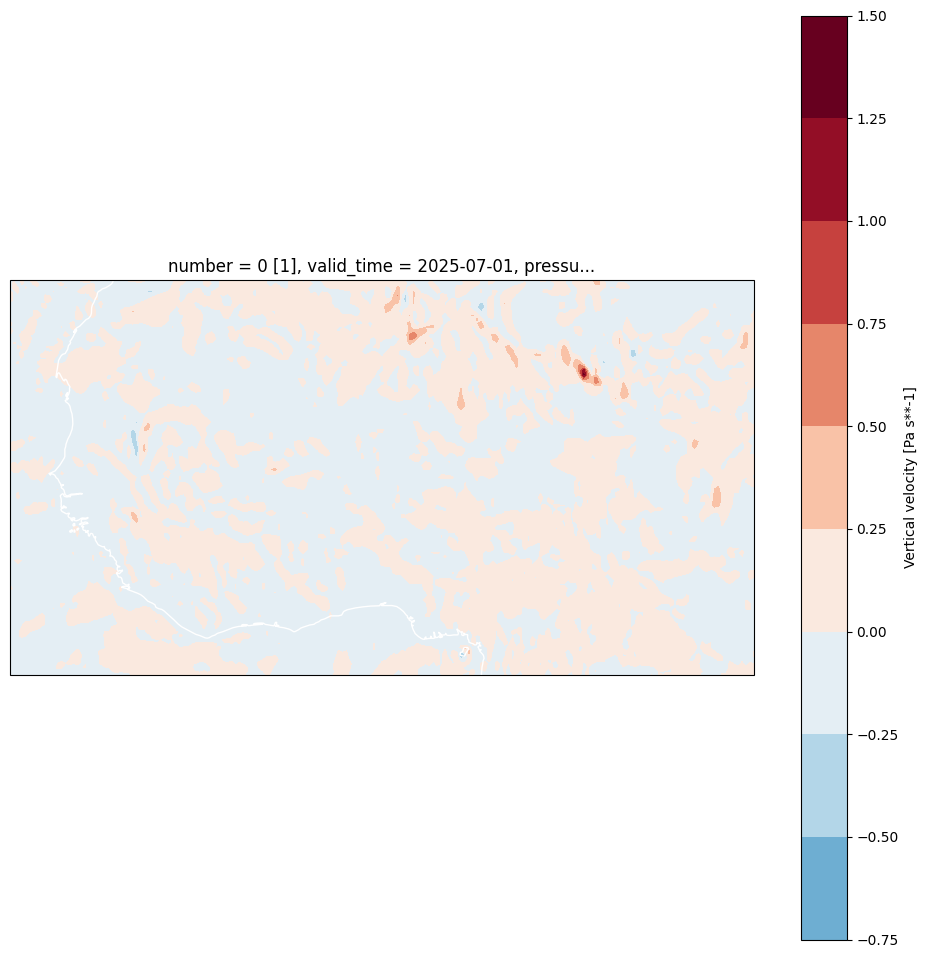

In [46]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
era5_sample['w'][0][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


### Load in PyEarthTools

As with the other datasets, we can create a dataaet accessor to abstract away the details of accessing the data.

In [47]:
ew4_era5_accessor = pyearthtools.data.archive.ew4_era5(variables=['temperature','specific_humidity', 'vertical_velocity'])

All selected variables present in the dataset.


In [48]:
ew4_era5_accessor[select_dt]

<xarray.Dataset> Size: 1MB
Dimensions:         (valid_time: 1, pressure_level: 5, latitude: 101,
                     longitude: 189)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8B 2025-07-23T09:00:00
  * pressure_level  (pressure_level) float64 40B 1e+03 850.0 700.0 500.0 200.0
  * latitude        (latitude) float64 808B 27.0 26.75 26.5 ... 2.5 2.25 2.0
  * longitude       (longitude) float64 2kB -20.0 -19.75 -19.5 ... 26.75 27.0
Data variables:
    t               (valid_time, pressure_level, latitude, longitude) float32 382kB dask.array<chunksize=(1, 2, 68, 126), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 382kB dask.array<chunksize=(1, 2, 68, 126), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 382kB dask.array<chunksize=(1, 2, 68, 126), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

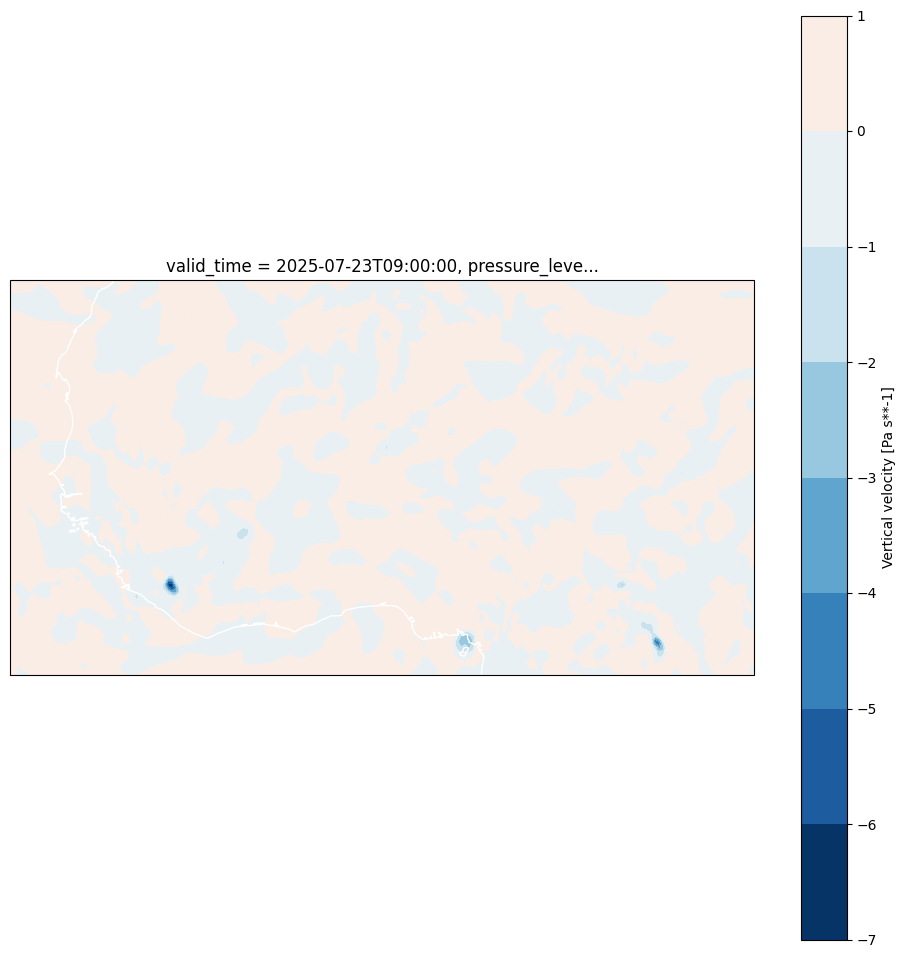

In [49]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_era5_accessor[select_dt].sel(pressure_level=500)['w'].squeeze().plot.contourf(ax=ax1)
ax1.coastlines(color='w')

